In [1]:
%%time
%matplotlib inline

import importlib
import new_import  

importlib.reload(new_import)


from new_import import *

CPU times: user 13.1 s, sys: 3.24 s, total: 16.4 s
Wall time: 10.3 s


In [2]:
%%time
# Cấu hình Daskgateway
cluster, client = notebook_utils.initialize_dask(use_gateway=True, workers=(1,10))
# Khai báo 1 Datacube là dc
dc = datacube.Datacube()

client

Starting new cluster.
CPU times: user 671 ms, sys: 68.2 ms, total: 739 ms
Wall time: 2min 43s


Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://hub.asia.easi-eo.solutions/services/dask-gateway/clusters/easihub.8daaa179e4964dc7b211b4302753bf26/status,


2025-01-18 10:50:14,308 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [3]:
date_range = ('2023-3-01', '2023-3-30')
longtitude_range = (105.5, 106.4)
latitude_range = (9.2, 10.0) 

coordinates = (longtitude_range, latitude_range)

In [4]:
# tải dữ liệu vh vv từ vệ tinh sentinel-1
dsvh, dsvv = load_data_sen1(dc, date_range, coordinates)

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 3, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 24B 2023-03-05T22:46:10.500000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    vv           (time, y, x) float32 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    vh           (time, y, x) float32 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [5]:
average_vh = calculate_average(dsvh, time_pattern='1M')
progress(average_vh)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [6]:
average_vv = calculate_average(dsvv, time_pattern='1M')
progress(average_vv)

/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

In [7]:
%%time
average_vh.compute()
average_vv.compute()

CPU times: user 764 ms, sys: 635 ms, total: 1.4 s
Wall time: 4min 38s


<xarray.DataArray 'vv' (time: 1, y: 8874, x: 9902)> Size: 351MB
array([[[0.19917326, 0.2036858 , 0.20597248, ..., 0.23972352,
         0.23907872, 0.23844711],
        [0.19917326, 0.2036858 , 0.20597248, ..., 0.25530738,
         0.25576517, 0.25507364],
        [0.20632547, 0.20605431, 0.2029686 , ..., 0.28056654,
         0.28108242, 0.27629215],
        ...,
        [0.06841445, 0.07078951, 0.07297197, ..., 0.06806423,
         0.06924058, 0.06730109],
        [0.07230996, 0.07190628, 0.07310792, ..., 0.06789783,
         0.06905217, 0.06681374],
        [0.07501791, 0.07259221, 0.07343484, ..., 0.06789783,
         0.06905217, 0.06681374]]], dtype=float32)
Coordinates:
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
  * time         (time) datetime64[ns] 8B 2023-03-31
Attributes:
    units:         intensity
    nodata:        nan
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [8]:
data_sen2 = load_data_sen2(dc, date_range, coordinates)
notebook_utils.heading(notebook_utils.xarray_object_size(data_sen2))
display(data_sen2)

No datasets require offset correction
The valid_data_mask and scale (no offset) have been applied to the reflectance bands


<xarray.Dataset> Size: 9GB
Dimensions:      (time: 12, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 96B 2023-03-01T03:35:09.182000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    red          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) float32 4GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    scl          (time, y, x) uint8 1GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

In [9]:
%%time
# Tiến hành loại bỏ các vị trí bị mây ảnh hưởng
result = mask_cloud(data_sen2)
progress(result)

{'0': 'no data',
 '1': 'saturated or defective',
 '2': 'dark area pixels',
 '3': 'cloud shadows',
 '4': 'vegetation',
 '5': 'bare soils',
 '6': 'water',
 '7': 'unclassified',
 '8': 'cloud medium probability',
 '9': 'cloud high probability',
 '10': 'thin cirrus',
 '11': 'snow or ice'}

CPU times: user 58.6 ms, sys: 480 μs, total: 59.1 ms
Wall time: 57.5 ms


VBox()

In [10]:
# calculate NDVI
dsNDVI = calculate_indices(result, index='NDVI', satellite_mission='s2')
ndvi = dsNDVI["NDVI"]
display(ndvi)


<xarray.DataArray 'NDVI' (time: 12, y: 8874, x: 9902)> Size: 4GB
dask.array<truediv, shape=(12, 8874, 9902), dtype=float32, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 96B 2023-03-01T03:35:09.182000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648

In [11]:
%%time
# calculate average NDVI
average_ndvi = calculate_average (ndvi,time_pattern="1M")
progress(average_ndvi)

CPU times: user 24.2 ms, sys: 0 ns, total: 24.2 ms
Wall time: 23.3 ms


/env/lib/python3.12/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


VBox()

2025-01-18 10:49:45,082 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7f40e8c330e0>>, <Task finished name='Task-412' coro=<MultiProgressBar.listen() done, defined at /env/lib/python3.12/site-packages/distributed/diagnostics/progressbar.py:281> exception=CommClosedError('in <TLS (closed)  local=tls://10.0.74.241:58968 remote=gateway://traefik-dask-gateway.easihub:80/easihub.8daaa179e4964dc7b211b4302753bf26>: Stream is closed')>)
Traceback (most recent call last):
  File "/env/lib/python3.12/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/env/lib/python3.12/s

In [12]:
average_ndvi = average_ndvi.compute()

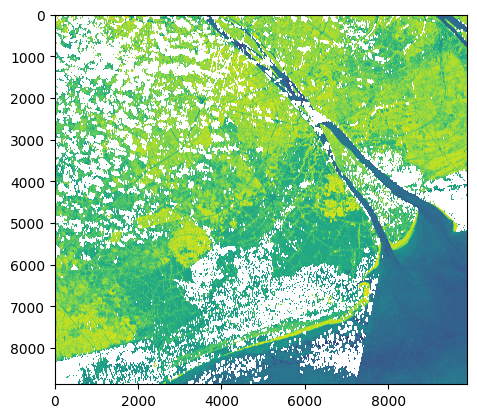

In [13]:
plt.imshow(average_ndvi.isel(time=0))

###########################################CALCULATE ACCURACY##########################################

In [68]:
fill_nan_model = joblib.load('output/regressors/max/gb_cloud.pkl')

In [64]:
mask = ~np.isnan(average_ndvi)
data = np.stack([average_vh.values[mask], average_vv.values[mask]], axis=1)
label = average_ndvi.values[mask]

In [65]:
num_samples = 1000

# Generate random indices
random_indices = np.random.choice(data.shape[0], size=num_samples, replace=False)

# Subset the data using the random indices
x = data[random_indices]
y = label[random_indices]

# Check the new shape
print(x.shape)
print(y.shape)

(1000, 2)
(1000,)


In [66]:
# np.savez("input/saved_datasets/test_aug.npz", data=x, label=y)

In [69]:
preds = fill_nan_model.predict(x)
mse = mean_squared_error(y, preds)
mae = mean_absolute_error(y, preds)
r2 = r2_score(y, preds)
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

MSE: 0.04130829795907553
MAE: 0.1617092873613522
R^2: 0.6916845336468708


#######################################DRAW GRAPH WITH DOTS##############################################

In [14]:
train_path = "input/train_points/1130/ST_1130_points.shp"  
# train_path = "train/updated_data/ThuanHoa_DKS_Kappa.shp"
ground_points = load_data_geo(train_path)
ground_points.head()

,No,X,Y,LU2022,Hientrang,HT_code,geometry
0,1.0,603860.819,1081162.862,Pomelo,CLN,3,POINT (603860.819 1081162.862)
1,2.0,601306.410,1082782.940,Pomelo,CLN,3,POINT (601306.41 1082782.94)
2,3.0,601084.510,1081351.870,Pomelo,CLN,3,POINT (601084.51 1081351.87)
3,4.0,602193.760,1079205.220,Pomelo,CLN,3,POINT (602193.76 1079205.22)
4,5.0,602459.000,1080946.000,Pomelo,CLN,3,POINT (602459 1080946)


In [57]:
fill_nan_model = joblib.load('output/regressors/mean_no_negative/rf_cloud.pkl')

In [16]:

def extract_data_with_HTcode(ground_points, average_ndvi, dsvh, dsvv):
    datasets = {}
    for idx, point in ground_points.iterrows():
        
        # Ensure each HT_code has its own dictionary
        if point.HT_code not in datasets:
            datasets[point.HT_code] = {'ndvi': [], 'vh': [], 'vv': []}
        # Get the data for this point
        ndvi_data = average_ndvi.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vh_data = dsvh.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vv_data = dsvv.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        
        # Append the data to the lists for this HT_code
        datasets[point.HT_code]['ndvi'].append(ndvi_data)
        datasets[point.HT_code]['vh'].append(vh_data)
        datasets[point.HT_code]['vv'].append(vv_data)
    
    return datasets

In [17]:
data = extract_data_with_HTcode(ground_points, average_ndvi, average_vh, average_vv)

In [361]:
index = 0

In [362]:
ndvi = np.concatenate(data[index]['ndvi'])
vh = np.concatenate(data[index]['vh'])
vv = np.concatenate(data[index]['vv'])
X_pred = np.stack([vh, vv], axis=1)
print(ndvi.shape, X_pred.shape)

(62,) (62, 2)


In [363]:
mask = ~np.isnan(ndvi)
nonan_ndvi = ndvi[mask]
nonan_ndvi.shape

(59,)

In [357]:
pred_data = X_pred[mask]
pred_data.shape

(55, 2)

In [349]:
pred_data = pred_data[:75]
nonan_ndvi = nonan_ndvi[:75]
pred_data.shape

(75, 2)

In [344]:
preds = fill_nan_model.predict(pred_data)

In [223]:
# print(nonan_ndvi)
# print(preds)

In [224]:
mae = mean_squared_error(nonan_ndvi, preds)
r2 = r2_score(preds, nonan_ndvi)
print("MAE: ", mae)
print("R^2: ", r2)

MAE:  0.062313261248912975
R^2:  0.3451370208505795


In [ ]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(nonan_ndvi, preds, color='blue', alpha=0.7, s=15)
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--', label='y = x')
# plt.plot( color='red', linestyle='--', label='y = x')
# Set equal scaling and adjust x and y axis limits from -1 to 1
plt.gca().set_aspect('equal', adjustable='box')
# plt.xlim(-1, 1)  # Set x-axis limits from -1 to 1
# plt.ylim(-1, 1)  # Set y-axis limits from -1 to 1

# Add minor ticks at intervals of 0.1
plt.xticks([i * 0.1 for i in range(-10, 11)], rotation=45)
plt.yticks([i * 0.1 for i in range(-10, 11)])

plt.xlabel('Actual NDVI')
plt.ylabel('Predicted NDVI')
plt.title('Comparison between Actual and Predicted NDVI LUA TOM')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


In [ ]:
##############################LOOP OVER 7 HT ##############

In [58]:
def draw_dots(nonan_ndvi, preds, label):
    plt.figure(figsize=(10, 6))
    plt.scatter(nonan_ndvi, preds, color='blue', alpha=0.7, s=15)
    plt.plot([-1, 1], [-1, 1], color='red', linestyle='--', label='y = x')
    # plt.plot( color='red', linestyle='--', label='y = x')
    # Set equal scaling and adjust x and y axis limits from -1 to 1
    plt.gca().set_aspect('equal', adjustable='box')
    # plt.xlim(-1, 1)  # Set x-axis limits from -1 to 1
    # plt.ylim(-1, 1)  # Set y-axis limits from -1 to 1
    # Add minor ticks at intervals of 0.1
    plt.xticks([i * 0.1 for i in range(-10, 11)], rotation=45)
    plt.yticks([i * 0.1 for i in range(-10, 11)])
    plt.xlabel('Actual NDVI')
    plt.ylabel('Predicted NDVI')
    plt.title('Comparison between Actual and Predicted NDVI ' + label) 
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

In [59]:
labels = ["LUA TOM", "LUA", "CHN", "CLN", "TS", "DXD", "RUNG"]
def get_data(data, labels):
    for index in range(0, 7):
        ndvi = np.concatenate(data[index]['ndvi'])
        vh = np.concatenate(data[index]['vh'])
        vv = np.concatenate(data[index]['vv'])
        X_pred = np.stack([vh, vv], axis=1)
        mask = ~np.isnan(ndvi)
        nonan_ndvi = ndvi[mask]
        pred_data = X_pred[mask]
        pred_data = pred_data[:75]
        nonan_ndvi = nonan_ndvi[:75]
        preds = fill_nan_model.predict(pred_data)
        draw_dots(nonan_ndvi, preds, labels[index])


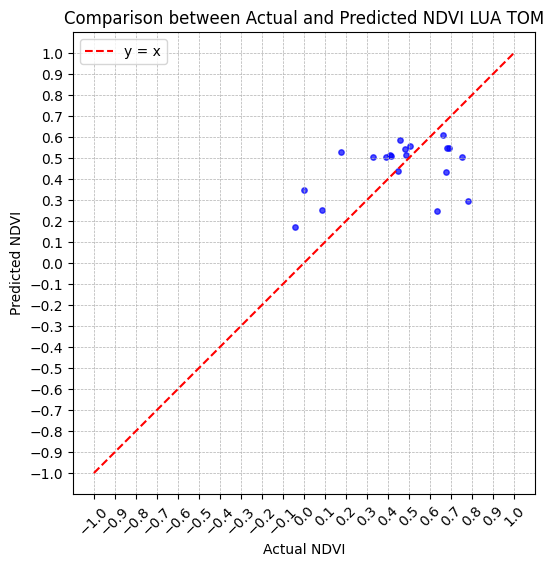

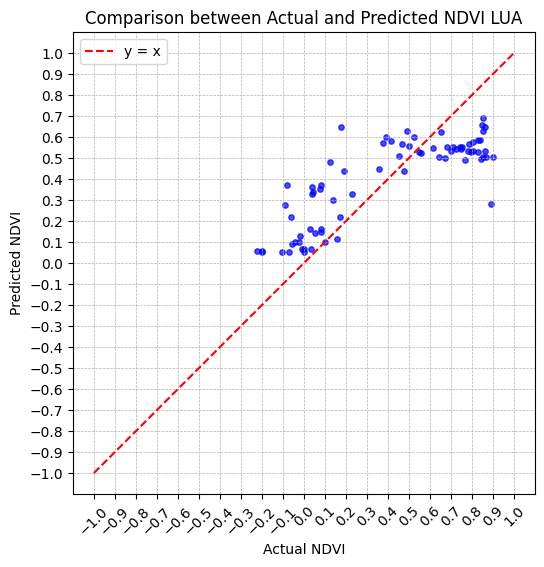

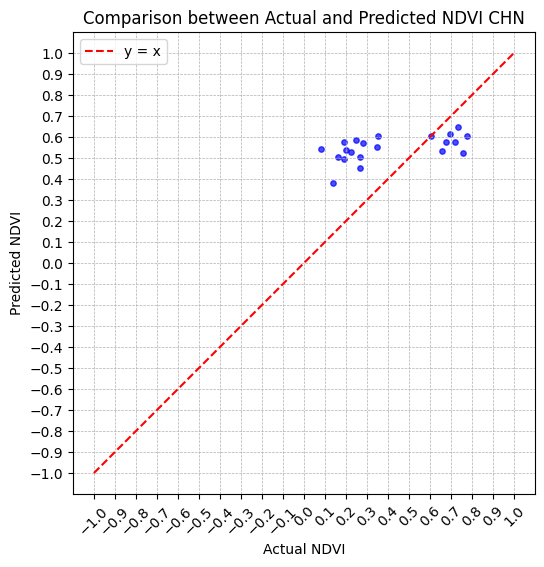

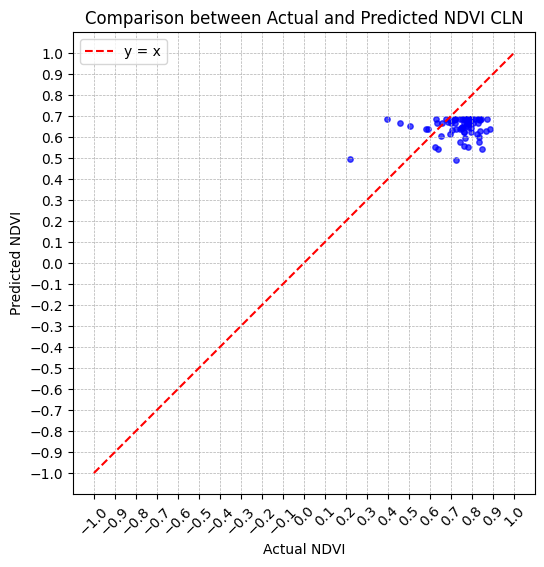

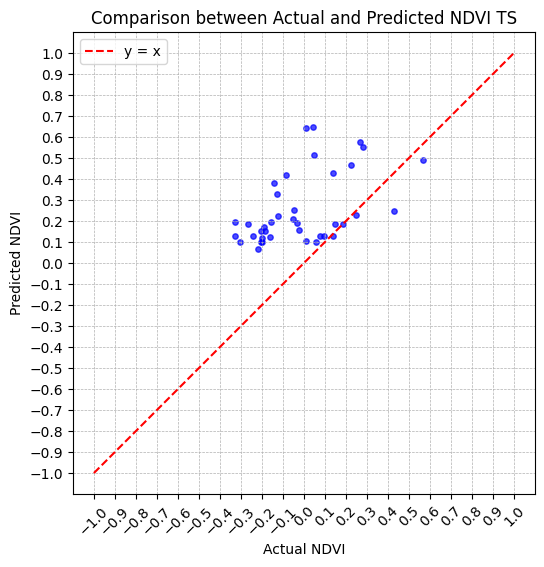

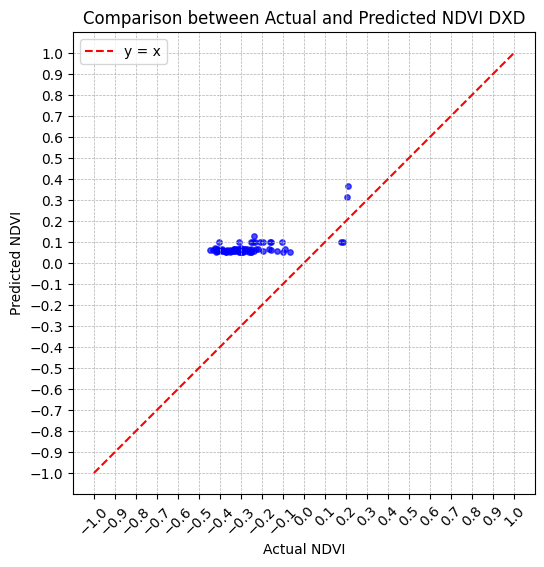

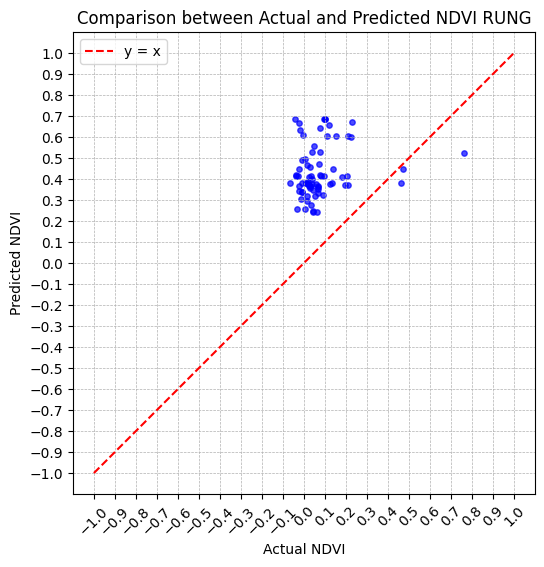

In [60]:
get_data(data, labels)

In [ ]:
for index in range(0, 7):
    ndvi = np.concatenate(data[index]['ndvi'])
    vh = np.concatenate(data[index]['vh'])
    vv = np.concatenate(data[index]['vv'])

    mask = ~np.isnan(ndvi)
    nonan_ndvi = ndvi[mask]
    pred_data = X_pred[mask]
    pred_data = pred_data[:75]
    nonan_ndvi = nonan_ndvi[:75]
    preds = fill_nan_model.predict(pred_data)
    draw_dots(nonan_ndvi, preds)
    

In [ ]:
###################################################################################################################

In [ ]:
import numpy as np

# Function to filter out NaN values for each 'ndvi' array in each HT_code
def filter_non_nan_ndvi(data):
    filtered_data = {}
    
    for ht_code, attributes in data.items():
        # Initialize lists to store filtered arrays for 'ndvi', 'vh', and 'vv'
        filtered_ndvi = []
        filtered_vh = []
        filtered_vv = []
        
        # Iterate through each set of ndvi, vh, vv arrays
        for ndvi, vh, vv in zip(attributes['ndvi'], attributes['vh'], attributes['vv']):
            # Create masks to filter out NaN values based on 'ndvi' array
            non_nan_mask = ~np.isnan(ndvi)
            
            # Filter the arrays based on the mask
            filtered_ndvi.append(ndvi[non_nan_mask])
            filtered_vh.append(vh[non_nan_mask])
            filtered_vv.append(vv[non_nan_mask])
        
        # Only add if there are non-empty filtered values
        filtered_data[ht_code] = {
            'ndvi': filtered_ndvi,
            'vh': filtered_vh,
            'vv': filtered_vv
        }
    
    return filtered_data

# Example usage
filtered_datasets = filter_non_nan_ndvi(data)



In [ ]:
filtered_datasets

In [ ]:
import numpy as np

# Set the range of indices you want to include
indices = range(0, 11)  # Selects indices from 0 to 10
ht_code = 1
# Initialize empty lists to hold data for the selected range
X_list = []
y_list = []

# Loop over the indices and collect data
for index in indices:
    vh_data = filtered_datasets[ht_code]['vh'][index]
    vv_data = filtered_datasets[ht_code]['vv'][index]
    ndvi_data = filtered_datasets[ht_code]['ndvi'][index]
    
    # Stack VH and VV data for the current index
    X = np.column_stack((vh_data, vv_data))
    X_list.append(X)
    y_list.append(ndvi_data)

# Concatenate the lists to form the complete dataset
X_combined = np.concatenate(X_list, axis=0)
y_combined = np.concatenate(y_list, axis=0)
print("X shape:", X_combined.shape)
print("y shape:", y_combined.shape)


In [ ]:
preds = fill_nan_model.predict(X_combined)
mse = mean_squared_error(y_combined, preds)
mae = mean_absolute_error(y_combined, preds)
r2 = r2_score(preds, y_combined)
print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")
# print(y)
# print(preds)

In [ ]:
import matplotlib.pyplot as plt
# Tạo biểu đồ với độ chia đồng nhất cho cả hai trục
# plt.figure(figsize=(10, 6))
plt.scatter(y_combined, preds, color='blue', alpha=0.7)
plt.plot([y_combined.min(), y_combined.max()],
         [y_combined.min(), y_combined.max()], color='red', linestyle='--', label='y = x')

# Thiết lập tỷ lệ các trục đồng nhất
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(y_combined.min() - 0.1, y_combined.max() + 0.1)  # Điều chỉnh giới hạn trục x
plt.ylim(y_combined.min() - 0.1, y_combined.max() + 0.1)  # Điều chỉnh giới hạn trục y

plt.xlabel('Actual NDVI')
plt.ylabel(' predicted NDVI')
plt.title('Comparing between actual and predict NDVI')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Assuming 'data' is the output of the function
ht_code = 1  # Replace with the specific HT code you want to extract
index = 3  # Replace with the index of the point you want to access (if multiple points are available)

# Extract the NDVI, VH, and VV values for that HT_code
ndvi_values = data[ht_code]['ndvi'][index]
vh_values = data[ht_code]['vh'][index]
vv_values = data[ht_code]['vv'][index]

# print("NDVI Values:", ndvi_values)
# print("VH Values:", vh_values)
# print("VV Values:", vv_values)

In [ ]:
print(data[ht_code]['vv'][index].shape)

In [ ]:
input_data = np.column_stack((vh_values, vv_values))

# Make predictions for each month
predicted_ndvi = fill_nan_model.predict(input_data)

# Print the predictions
print("Predicted NDVI for each month:", predicted_ndvi)

In [ ]:
plt.plot(ndvi_values, marker='o', linestyle='-', color='b', label='Actual Values')

# Plotting the adjusted values
plt.plot(predicted_ndvi, marker='x', linestyle='--', color='r', label='Predicted Values')

# Adding labels and title
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Comparison: Actual vs predicted Values in CLN code over 24 months')
# Adding grid
plt.grid(True)
# Adding legend to differentiate the lines
plt.legend()
# # # Adjusting the limits of the axes
# plt.xlim(0, 75)  # Example: Setting x-axis limits from 0 to 12
# plt.ylim(-1, 1)   # Example: Setting y-axis limits from 0 to 1
# Display the plot
plt.show()

In [ ]:
# cấu hình nhãn dữ liệu
label_mapping = {
    "Lua tom": "0",
    "Lua": "1",
    "CHN": "2",
    "CLN": "3",
    "TS": "4",
    "Song": "5",
    "Dat xay dung": "6",
    "Rung": "7"
}

In [ ]:
def draw(ndvi_values, predicted_ndvi, name):
    plt.plot(ndvi_values, marker='o', linestyle='-', color='b', label='Actual Values')
    plt.plot(predicted_ndvi, marker='x', linestyle='--', color='r', label='Predicted Values')
    # Adding labels and title
    plt.xlabel('Index')
    plt.ylabel('Values')
    plt.title(f'Comparison: Actual vs predicted Values in {name} code over 24 months')
    # Adding grid
    plt.grid(True)
    # Adding legend to differentiate the lines
    plt.legend()
    # # # Adjusting the limits of the axes
    plt.xlim(0, 25)  # Example: Setting x-axis limits from 0 to 12
    plt.ylim(-1, 1)   # Example: Setting y-axis limits from 0 to 1
    # Display the plot
    plt.show()

In [ ]:
def show_images (ht_code, index, name):
    ndvi_values = data[ht_code]['ndvi'][index]
    vh_values = data[ht_code]['vh'][index]
    vv_values = data[ht_code]['vv'][index]
    input_data = np.column_stack((vh_values, vv_values))
    predicted_ndvi = fill_nan_model.predict(input_data)
    draw(ndvi_values, predicted_ndvi, name)
    

In [ ]:
for i in range(50):
    show_images(1, i, 'TS')

In [ ]:
plt.plot(data[6]['ndvi'], marker='x', linestyle='--', color='b')
    # Adding labels and title
plt.xlabel('Index')
plt.ylabel('Values')
plt.title(f'NDVI values')
# Adding grid
plt.grid(True)
# Adding legend to differentiate the lines
plt.legend()
# # # Adjusting the limits of the axes
# plt.xlim(0, 25)  # Example: Setting x-axis limits from 0 to 12
plt.ylim(-1, 1)   # Example: Setting y-axis limits from 0 to 1
# Display the plot
plt.show()